In [7]:
import msi_visual
from msi_visual.parametric_mics_lmc import MSIParametricMiCSLMC
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import torch
from msi_visual.utils import normalize
from PIL import Image
from pcc import PCC
import cv2

#path = r"E:\MSImaging-data\_msi_visual\Extractions\Metaspace_datasets\Dataset4_kidney"
path = r"E:\\MSImaging-data\\_msi_visual\\Extractions\\NRL4485-s2\\10_bins"
X =  np.load(path + r"\0.npy")
X = X / (1e-6 + X.sum(axis=-1, keepdims=True))
X = np.float32(X).copy()
X = X.transpose().transpose(1, 2, 0)[::-1, :, :].copy()
X_1d = np.reshape(X, (-1, X.shape[-1])).copy()
X_raw = X_1d.copy()
print(X_raw.shape, X.shape)


# Create and train the model
model = MSIParametricMiCSLMC(
    number_of_points=1000,
    sampling="random",
    num_epochs=100,
    number_of_components=3,
    verbose=False,
    lab_to_rgb=True,
    cluster=True,
    #clusters=[32, 64, 128, 256, 512],
    clusters=[128,256,512],
    num_samples=5000,
    beta=1.0,
    k_epoch=1,
    temperature=20.0,
    lr=1.0,
    batch_size=1024,
    warmup_epochs=10,
    factor=1.0,
    random_state=42
)

# Fit the model on X (this initializes and trains in one call)
model.fit(X)

(74932, 10510) (286, 262, 10510)


100%|██████████| 100/100 [00:27<00:00,  3.59it/s]


Parametric PCC Optimization: num_epochs: 100             sampling: random number_of_points:1000 cluster: True

E:\\MSImaging-data\\_msi_visual\\Extractions\\NRL4485-s2\\10_bins


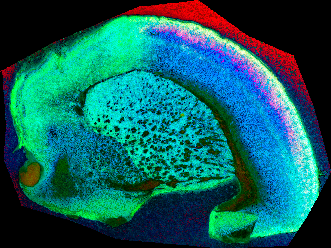

In [20]:
import glob
def visualize(model, path, transpose=False):
    print(path)
    for img_path in sorted(glob.glob(path + r"\\*.npy"))[1: ]:
        img = np.load(img_path)
        img = img / (1e-6 + img.sum(axis=-1, keepdims=True))
        img = np.float32(img).copy()
        if transpose:
            img = img.transpose().transpose(1, 2, 0)[::-1, :, :].copy()
        viz = model.predict(img)
        display(Image.fromarray(cv2.merge([cv2.equalizeHist(viz[:,:,i]) for i in range(viz.shape[2])])))
        return img, viz

from msi_visual.metrics import MSIVisualizationMetrics
img, viz = visualize(model, path)
#metrics = MSIVisualizationMetrics(img, viz, num_samples=3000)
#metrics.get_metrics()

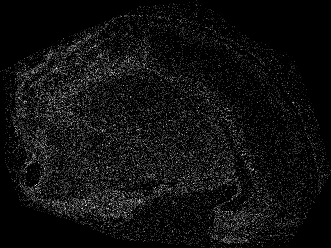

In [23]:
import glob
def get_uncertainty(model, path, transpose=False):
    for img_path in sorted(glob.glob(path + r"\*.npy"))[1: ]:
        img = np.load(img_path)
        img = img / (1e-6 + img.sum(axis=-1, keepdims=True))
        img = np.float32(img).copy()
        if transpose:
            img = img.transpose().transpose(1, 2, 0)[::-1, :, :].copy()
        viz = model.uncertainty(img)
        return viz

uncertainty = get_uncertainty(model, path)
uncertainty = uncertainty - uncertainty.min()
uncertainty=  uncertainty / uncertainty.max()
uncertainty = np.uint8(255 * uncertainty)
uncertainty = cv2.merge([uncertainty, uncertainty, uncertainty])    
display(Image.fromarray(uncertainty))



(248, 331) uint8


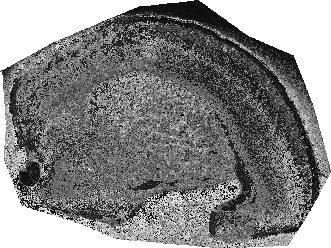

In [43]:
diff = np.abs(viz1 - viz).mean(axis=-1)
diff = diff - diff.min()
diff = diff / diff.max()

diff = np.exp(-diff * 5)
diff = diff - diff.min()
diff = diff / diff.max()

diff = np.uint8(255 * diff)
#diff = cv2.equalizeHist(diff)
print(diff.shape, diff.dtype)
display(Image.fromarray(diff))

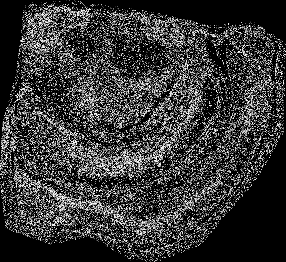

In [4]:
display(Image.fromarray(cv2.merge([cv2.equalizeHist(uncertainty[:,:,i]) for i in range(uncertainty.shape[2])])))

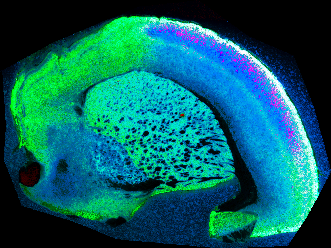

In [44]:
import glob
def visualize(model, path, transpose=False):
    for img_path in sorted(glob.glob(path + r"\*.npy"))[1: ]:
        img = np.load(img_path)
        img = img / (1e-6 + img.sum(axis=-1, keepdims=True))
        img = np.float32(img).copy()
        if transpose:
            img = img.transpose().transpose(1, 2, 0)[::-1, :, :].copy()

        # For each pixel, zero out the top k=10 values (across the last dim)
        k = 10
        img_for_zero = img
        # Flatten x,y for easier manipulation, then reshape back
        flat_img = img_for_zero.reshape(-1, img_for_zero.shape[-1])
        # argsort for descending order, axis=-1
        topk_indices = np.argpartition(-flat_img, kth=np.arange(k), axis=1)[:, k : ]
        # set topk indices to zero for each row
        row_indices = np.arange(flat_img.shape[0])[:, None]
        flat_img[row_indices, topk_indices] = 0
        img = flat_img.reshape(img_for_zero.shape)

        viz = model.predict(img)
        display(Image.fromarray(cv2.merge([cv2.equalizeHist(viz[:,:,i]) for i in range(viz.shape[2])])))
        return img, viz

from msi_visual.metrics import MSIVisualizationMetrics
img, viz1 = visualize(model, path)
#metrics = MSIVisualizationMetrics(img, viz, num_samples=3000)
#metrics.get_metrics()

In [6]:
viz2 = np.array(Image.open(r"E:\MSImaging-data\_msi_visual\Benchmarking\METASPACE slides\metaspace_benchmark_subset\kidney_SaliencyOptimization.png"))
viz2 = cv2.merge([cv2.equalizeHist(viz2[:,:,i]) for i in range(viz2.shape[2])])
metrics = MSIVisualizationMetrics(img, viz2, num_samples=3000)
metrics.get_metrics()

ValueError: cannot reshape array of size 1359600 into shape (74932,newaxis)

In [ ]:
viz3 = np.array(Image.open(r"C:\Users\PahnkeLab\Desktop\maldi_msi\outputs\2025-12-28 _ kidney 5µm\parametric_mics_lmc_20251228_102127\0_viz.png"))
metrics = MSIVisualizationMetrics(img, viz3, num_samples=3000)
metrics.get_metrics()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\PahnkeLab\\Desktop\\maldi_msi\\outputs\\2025-12-28 _ kidney 5µm\\parametric_mics_lmc_20251228_102127\\0_viz.png'

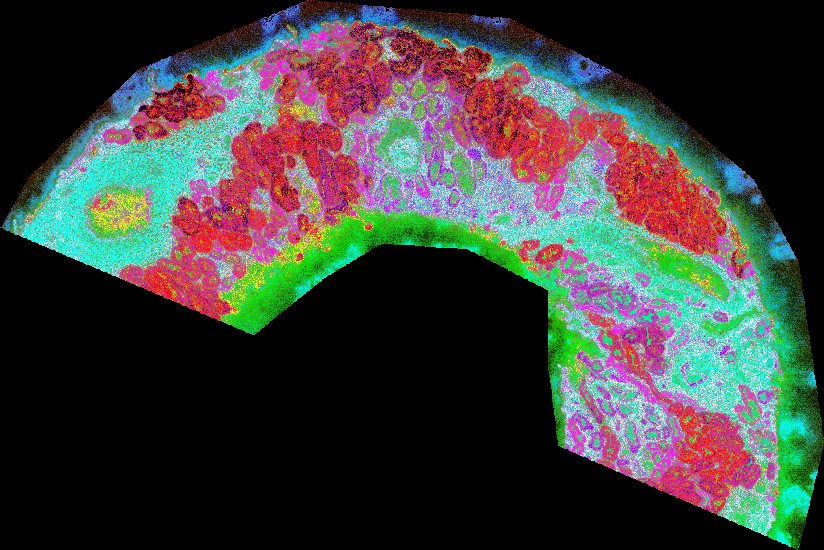

In [ ]:
display(Image.fromarray(viz3))

In [ ]:
model.

Parametric PCC Optimization: num_epochs: 100             sampling: coreset number_of_points:1000 cluster: True

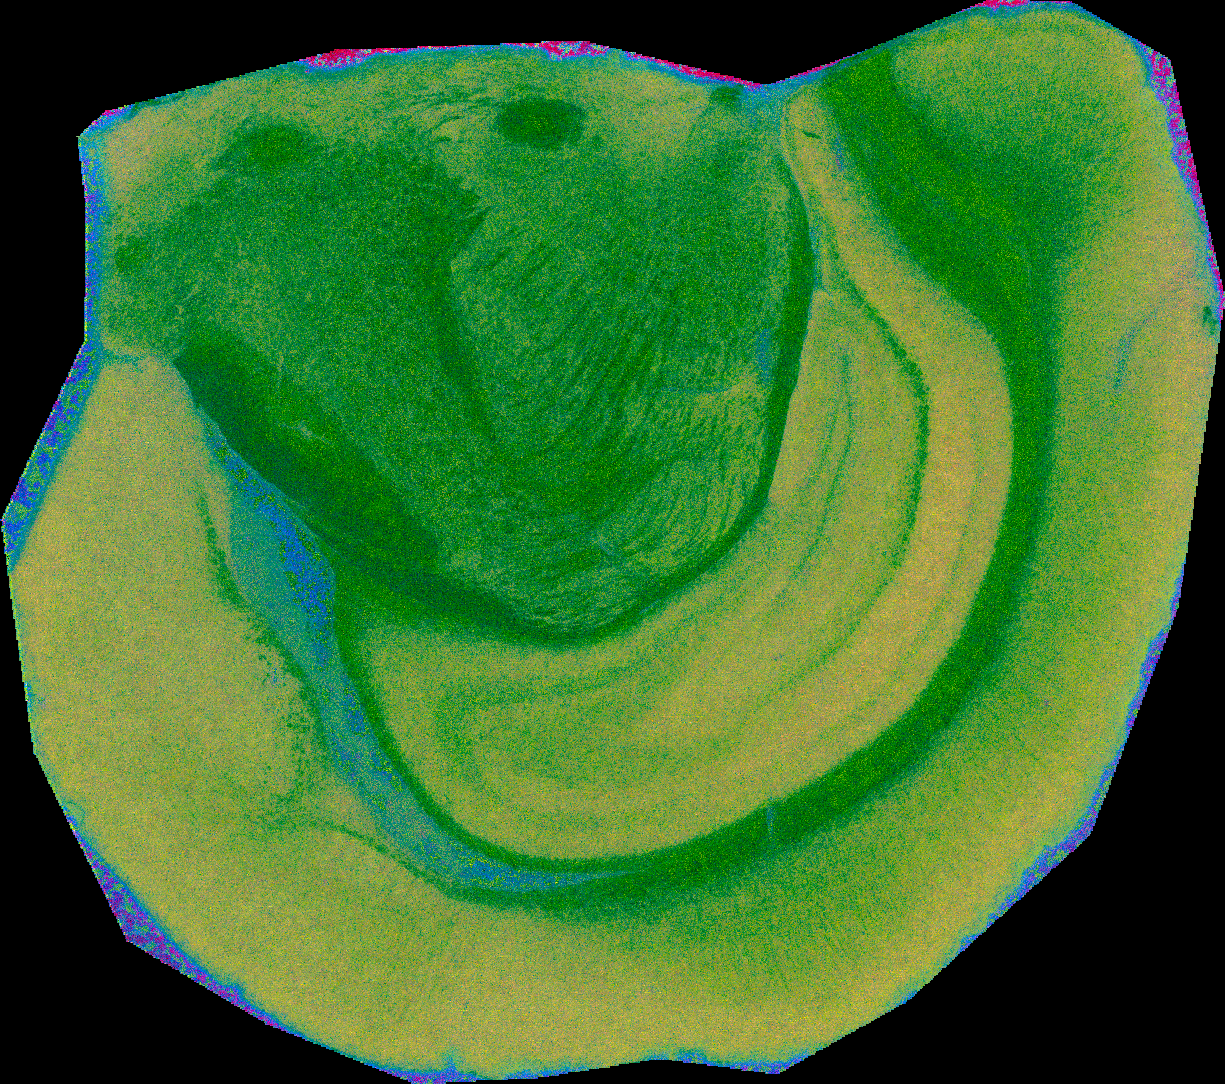

In [ ]:
display(Image.fromarray(viz))